In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

In [45]:
df = pd.read_csv("dataset_particulas_unificado_F.csv")
df.head()

,pt,eta,phi,particle_type,event_id
0,2.06272,-0.233066,-0.154099,electron,1203594102
1,2.65992,2.005970,-2.187040,electron,1203594102
2,27.85330,-1.332450,1.910920,tau,1203594102
3,1.58189,-1.451010,-0.961732,tau,1203594102
4,2.12971,-1.054230,-2.037100,tau,1203594102


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10769 entries, 0 to 10768
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pt             10769 non-null  float64
 1   eta            10769 non-null  float64
 2   phi            10769 non-null  float64
 3   particle_type  10769 non-null  object 
 4   event_id       10769 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 420.8+ KB


In [47]:
# Features
X = df[['pt', 'eta', 'phi', 'event_id']]

# Target
y = df['particle_type']

# Entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [50]:
%%time
# Escalador
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Modelo
logreg = LogisticRegression(
    max_iter=2000,
    multi_class='multinomial',
    solver='lbfgs'
)

# Entrenamiento ÚNICO
logreg.fit(X_train_scaled, y_train)


CPU times: user 136 ms, sys: 767 µs, total: 137 ms
Wall time: 136 ms


LogisticRegression(max_iter=2000, multi_class='multinomial')

In [51]:
y_pred = logreg.predict(X_test_scaled)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

    electron       0.00      0.00      0.00        16
        muon       0.00      0.00      0.00        38
      photon       0.29      0.06      0.10        34
         tau       0.71      0.30      0.42      1130
       track       0.70      0.96      0.81      2013

    accuracy                           0.70      3231
   macro avg       0.34      0.26      0.27      3231
weighted avg       0.69      0.70      0.65      3231



/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


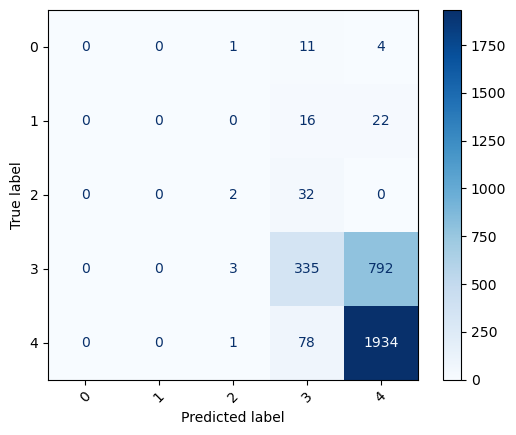

In [52]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.show()

/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


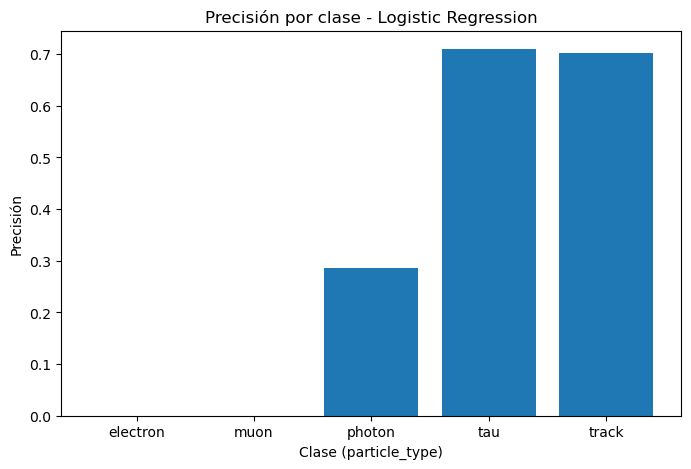

In [53]:
from sklearn.metrics import precision_score

# Obtener precisiones por clase
labels = sorted(y.unique())
precisiones = precision_score(y_test, y_pred, average=None, labels=labels)

# Graficar
plt.figure(figsize=(8,5))
plt.bar(labels, precisiones)
plt.xlabel("Clase (particle_type)")
plt.ylabel("Precisión")
plt.title("Precisión por clase - Logistic Regression")
plt.show()


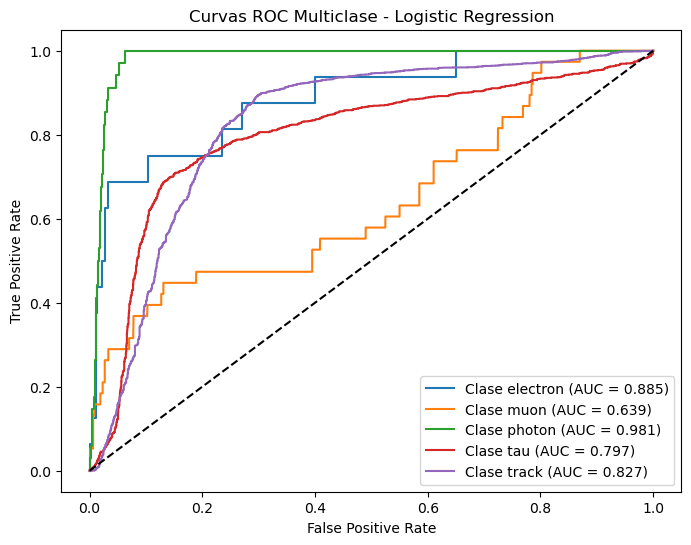

In [54]:
# Binarización de etiquetas
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = logreg.predict_proba(X_test_scaled)

plt.figure(figsize=(8,6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Clase {cls} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC Multiclase - Logistic Regression")
plt.legend()
plt.show()

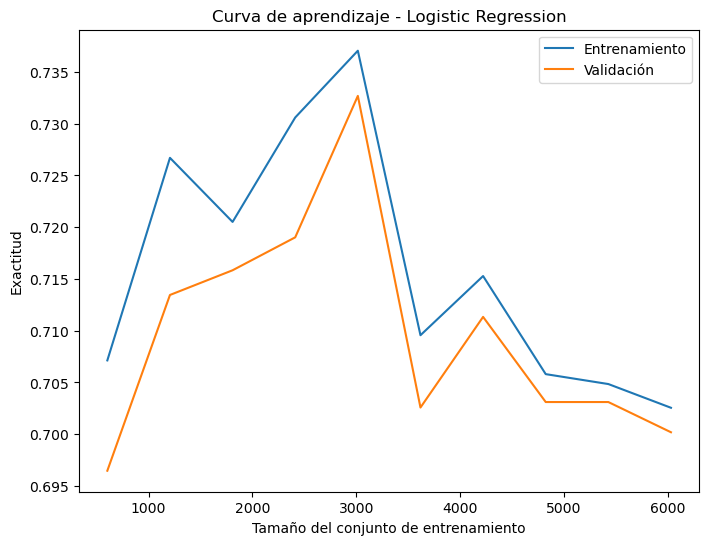

In [55]:
train_sizes, train_scores, test_scores = learning_curve(
    logreg,
    X_train_scaled,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Entrenamiento")
plt.plot(train_sizes, test_mean, label="Validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de aprendizaje - Logistic Regression")
plt.legend()
plt.show()
